# Monte Carlo Simulation of a T20I Cricket Match
## India vs South Africa, 2024 Series

**Objective:** Use empirical ball-by-ball delivery data to build probability distributions,
then run Monte Carlo simulations to project match outcomes at **three levels of detail**:

| Level | What it outputs | Key insight |
|-------|----------------|-------------|
| **Level 1 — Total Scores** | Distribution of projected team totals | "What's the most likely score India will post?" |
| **Level 2 — Full Scorecard** | Per-batter stats (runs, balls, 4s, 6s, SR) | "How does each batter contribute?" |
| **Level 3 — Ball-by-Ball** | Complete delivery log for one simulated innings | "What does a single simulated match look like?" |

---

## Design Choices & Methodology

### i) Level of Detail: Ball-by-Ball Outcomes

We simulate at the **ball-by-ball level** because:
- It is the most granular — every legal delivery is simulated individually.
- Higher-level outputs (scorecards, total scores) are **derived automatically** from the ball-by-ball log.
- It correctly handles cricket rules: strike rotation, over boundaries, wickets, extras.

### ii) Major Random Variables

The primary random variable is the **outcome of each delivery**. For every ball, we sample
from $15$ discrete event categories:

$$X_{\text{delivery}} \sim \text{Categorical}(p_1, p_2, \ldots, p_{15})$$

where $p_i$ is the empirical probability of event $i$ for a specific **batter-vs-bowler matchup**.

The 15 events are: `dot_ball, single, double, triple, four, five, six, wide, no_ball, leg_bye, bye, caught, bowled, lbw, other_wicket`.

### iii) Distribution Type: Empirical Categorical

We use an **empirical (data-driven) categorical distribution**:
- For each (batter, bowler) pair, we count how many times each of the 15 events occurred in the historical data.
- We normalize these counts to get a probability mass function (PMF).
- We sample from this PMF using `np.random.choice` with the computed probabilities.

**Why not a parametric distribution (e.g., Poisson for runs)?**
- Runs per ball are *not* well-modeled by standard distributions (they have heavy spikes at 0, 1, 4, and 6).
- The empirical distribution captures the actual shape of the data without imposing assumptions.
- Categorical sampling is computationally cheap — drawing one sample is $O(K)$ where $K=15$.

### Fallback Mechanism

If a batter-bowler pair has **no historical data** (they never faced each other in the dataset),
we fall back to the **batter's overall career distribution** against all bowlers.
This avoids zero-probability errors while still being data-driven.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Data Ingestion and Preprocessing

We load the ball-by-ball dataset `ind_rsa_4_t20i_2024_deliveries.csv`.

Each row represents a single delivery (ball bowled) and contains:
- **Match context**: `match_id`, `season`, `date`, `venue`, `innings`
- **Players**: `striker` (batter on strike), `bowler`
- **Outcome**: `runs_of_bat`, `extras`, `wide`, `legbyes`, `byes`, `noballs`
- **Wicket info**: `wicket_type`, `player_dismissed`, `fielder`

The dataset covers **4 T20I matches** between India and South Africa in November 2024.

In [2]:
# Load the ball-by-ball delivery dataset
df = pd.read_csv('ind_rsa_4_t20i_2024_deliveries.csv')
print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(10)

Dataset shape: (984, 21)
Columns: ['match_id', 'season', 'phase', 'match_no', 'date', 'venue', 'batting_team', 'bowling_team', 'innings', 'over', 'striker', 'bowler', 'runs_of_bat', 'extras', 'wide', 'legbyes', 'byes', 'noballs', 'wicket_type', 'player_dismissed', 'fielder']


,match_id,season,phase,match_no,date,venue,batting_team,bowling_team,innings,over,...,bowler,runs_of_bat,extras,wide,legbyes,byes,noballs,wicket_type,player_dismissed,fielder
0,202401,2024,Group Stage,1,"Nov 08, 2024","Kingsmead, Durban",IND,RSA,1,0.1,...,Marco Jansen,1,0,0,0,0,0,NaN,NaN,NaN
1,202401,2024,Group Stage,1,"Nov 08, 2024","Kingsmead, Durban",IND,RSA,1,0.2,...,Marco Jansen,0,0,0,0,0,0,NaN,NaN,NaN
2,202401,2024,Group Stage,1,"Nov 08, 2024","Kingsmead, Durban",IND,RSA,1,0.3,...,Marco Jansen,0,0,0,0,0,0,NaN,NaN,NaN
3,202401,2024,Group Stage,1,"Nov 08, 2024","Kingsmead, Durban",IND,RSA,1,0.4,...,Marco Jansen,1,0,0,0,0,0,NaN,NaN,NaN
4,202401,2024,Group Stage,1,"Nov 08, 2024","Kingsmead, Durban",IND,RSA,1,0.5,...,Marco Jansen,0,0,0,0,0,0,NaN,NaN,NaN
5,202401,2024,Group Stage,1,"Nov 08, 2024","Kingsmead, Durban",IND,RSA,1,0.6,...,Marco Jansen,0,0,0,0,0,0,NaN,NaN,NaN
6,202401,2024,Group Stage,1,"Nov 08, 2024","Kingsmead, Durban",IND,RSA,1,1.1,...,Markram,4,0,0,0,0,0,NaN,NaN,NaN
7,202401,2024,Group Stage,1,"Nov 08, 2024","Kingsmead, Durban",IND,RSA,1,1.2,...,Markram,1,0,0,0,0,0,NaN,NaN,NaN
8,202401,2024,Group Stage,1,"Nov 08, 2024","Kingsmead, Durban",IND,RSA,1,1.3,...,Markram,0,0,0,0,0,0,NaN,NaN,NaN
9,202401,2024,Group Stage,1,"Nov 08, 2024","Kingsmead, Durban",IND,RSA,1,1.4,...,Markram,4,0,0,0,0,0,NaN,NaN,NaN


In [3]:
# Basic info about the dataset
print(f'Number of matches: {df["match_id"].nunique()}')
print(f'Match IDs: {sorted(df["match_id"].unique())}')
print(f'\nInnings distribution:')
print(df.groupby(['match_id', 'innings', 'batting_team']).size().reset_index(name='deliveries'))
print(f'\nWicket types found: {df["wicket_type"].dropna().unique()}')

Number of matches: 4
Match IDs: [np.int64(202401), np.int64(202402), np.int64(202403), np.int64(202404)]

Innings distribution:
   match_id  innings batting_team  deliveries
0    202401        1          IND         126
1    202401        2          RSA         112
2    202402        1          IND         128
3    202402        2          RSA         117
4    202403        1          IND         131
5    202403        2          RSA         121
6    202404        1          IND         133
7    202404        2          RSA         116

Wicket types found: ['caught' 'runout' 'lbw' 'bowled' 'stumped']


## 1b. Roster Extraction

We dynamically extract all player names for both teams from the dataset.
A player can appear as a `striker` (when batting) or as a `bowler` (when bowling).
We take the union of both to get the full squad.

In [4]:
def extract_rosters(df):
    """
    Extract unique player lists for each team from the dataset.
    A player appears as either a striker (batting) or bowler (bowling).
    """
    teams = df['batting_team'].unique()
    rosters = {}
    for team in teams:
        batters = set(df[df['batting_team'] == team]['striker'].unique())
        bowlers = set(df[df['bowling_team'] == team]['bowler'].unique())
        rosters[team] = sorted(batters | bowlers)
    return rosters

rosters = extract_rosters(df)
for team, players in rosters.items():
    print(f'\n{team} roster ({len(players)} players):')
    for i, p in enumerate(players, 1):
        print(f'  {i}. {p}')


IND roster (12 players):
  1. Abhishek Sharma
  2. Arshdeep Singh
  3. Avesh Khan
  4. Axar
  5. Hardik Pandya
  6. Ramandeep Singh
  7. Ravi Bishnoi
  8. Rinku Singh
  9. Samson
  10. Suryakumar Yadav
  11. Tilak Varma
  12. Varun Chakaravarthy

RSA roster (13 players):
  1. Gerald Coetzee
  2. Klaasen
  3. Maharaj
  4. Marco Jansen
  5. Markram
  6. Miller
  7. Nqabayomzi Peter
  8. Patrick Kruger
  9. Reeza Hendricks
  10. Rickelton
  11. Simelane
  12. Sipamla
  13. Tristan Stubbs


## 2. Event Classification

Every ball bowled in the dataset is classified into one of **15 predefined event categories**.

The classification uses **priority logic**:
1. **Wickets** are checked first (highest priority) — even if runs were scored, a wicket dominates
2. **Extras** (wide, no-ball, leg-bye, bye) are checked next
3. **Runs off the bat** (0–6) are the default

| Index | Event | Description | Runs added | Legal ball? | Strike swap? |
|-------|-------|-------------|------------|------------|-------------|
| 0 | `dot_ball` | 0 runs, no extras, no wicket | 0 | ✅ | ❌ |
| 1 | `single` | 1 run off bat | 1 | ✅ | ✅ |
| 2 | `double` | 2 runs off bat | 2 | ✅ | ❌ |
| 3 | `triple` | 3 runs off bat | 3 | ✅ | ✅ |
| 4 | `four` | Boundary 4 | 4 | ✅ | ❌ |
| 5 | `five` | 5 runs (rare, overthrows) | 5 | ✅ | ✅ |
| 6 | `six` | Boundary 6 | 6 | ✅ | ❌ |
| 7 | `wide` | Wide delivery | 1 | ❌ | ❌ |
| 8 | `no_ball` | No-ball delivery | 1 | ❌ | ❌ |
| 9 | `leg_bye` | Leg bye (1 run) | 1 | ✅ | ✅ |
| 10 | `bye` | Bye (1 run) | 1 | ✅ | ✅ |
| 11 | `caught` | Caught out | 0 | ✅ | New batter |
| 12 | `bowled` | Bowled out | 0 | ✅ | New batter |
| 13 | `lbw` | Leg before wicket | 0 | ✅ | New batter |
| 14 | `other_wicket` | Run out, stumped, etc. | 0 | ✅ | New batter |

In [5]:
# Define the 15 event categories
EVENT_CATEGORIES = [
    'dot_ball',      # 0: no runs
    'single',        # 1: 1 run off bat
    'double',        # 2: 2 runs off bat
    'triple',        # 3: 3 runs off bat
    'four',          # 4: boundary 4
    'five',          # 5: 5 runs (rare)
    'six',           # 6: boundary 6
    'wide',          # 7: wide delivery (+1 run, not a legal ball)
    'no_ball',       # 8: no-ball (+1 run, not a legal ball)
    'leg_bye',       # 9: leg bye (+1 run)
    'bye',           # 10: bye (+1 run)
    'caught',        # 11: wicket - caught
    'bowled',        # 12: wicket - bowled
    'lbw',           # 13: wicket - LBW
    'other_wicket',  # 14: wicket - run out, stumped, etc.
]

EVENT_TO_IDX = {e: i for i, e in enumerate(EVENT_CATEGORIES)}
NUM_EVENTS = len(EVENT_CATEGORIES)


def classify_delivery(row):
    """
    Classify a single delivery into one of 15 event categories.

    Priority: Wickets > Extras > Runs off bat
    """
    wicket_type = row['wicket_type']

    # 1. WICKETS (highest priority)
    if pd.notna(wicket_type) and wicket_type != '':
        wt = str(wicket_type).strip().lower()
        if wt == 'caught':   return 'caught'
        elif wt == 'bowled': return 'bowled'
        elif wt == 'lbw':    return 'lbw'
        else:                return 'other_wicket'  # runout, stumped, etc.

    # 2. EXTRAS
    if row['wide'] > 0:    return 'wide'
    if row['noballs'] > 0: return 'no_ball'
    if row['legbyes'] > 0: return 'leg_bye'
    if row['byes'] > 0:    return 'bye'

    # 3. RUNS OFF THE BAT
    runs = int(row['runs_of_bat'])
    run_events = {0: 'dot_ball', 1: 'single', 2: 'double', 3: 'triple',
                  4: 'four', 5: 'five', 6: 'six'}
    return run_events.get(runs, 'dot_ball')


# Apply classification to every delivery
df['event'] = df.apply(classify_delivery, axis=1)

print('Event distribution across all deliveries:')
print(df['event'].value_counts().sort_index())
print(f'\nTotal deliveries classified: {len(df)}')

Event distribution across all deliveries:
event
bowled           11
bye               2
caught           31
dot_ball        303
double           48
four            108
lbw               7
leg_bye          10
no_ball           7
other_wicket      6
single          317
six              84
triple            4
wide             46
Name: count, dtype: int64

Total deliveries classified: 984


## 3. Empirical Probability Calculation

### How probabilities are computed

For each **(batter, bowler)** pair, we:
1. Filter all deliveries where this batter faced this bowler
2. Count the frequency of each of the 15 events
3. Normalize to get a probability mass function (PMF)

$$p_i^{(b, w)} = \frac{\text{count of event } i \text{ for batter } b \text{ vs bowler } w}{\text{total deliveries for batter } b \text{ vs bowler } w}$$

### Fallback Mechanism

If batter $b$ has **never faced** bowler $w$ in the dataset:
$$p_i^{(b, w)} \leftarrow p_i^{(b, \text{all})} = \frac{\text{count of event } i \text{ for batter } b \text{ vs ALL bowlers}}{\text{total deliveries for batter } b}$$

This ensures we always have a valid probability distribution.

In [6]:
def compute_matchup_probabilities(df, batting_team, bowling_team):
    """
    Compute empirical probability distributions for all batter-bowler matchups.

    For each (batter, bowler) pair:
      - Count frequency of each of the 15 events
      - Normalize to get probabilities

    Fallback: if no data for a specific matchup, use the batter's
    overall distribution against all bowlers.
    """
    innings_df = df[df['batting_team'] == batting_team].copy()
    batters = innings_df['striker'].unique()
    bowlers = innings_df['bowler'].unique()

    # Compute batter-level fallback distributions
    batter_overall = {}
    for batter in batters:
        batter_df = innings_df[innings_df['striker'] == batter]
        event_counts = batter_df['event'].value_counts()
        total = event_counts.sum()
        probs = np.zeros(NUM_EVENTS)
        for evt, count in event_counts.items():
            if evt in EVENT_TO_IDX:
                probs[EVENT_TO_IDX[evt]] = count / total
        batter_overall[batter] = probs

    # Compute matchup-specific distributions
    records = []
    for batter in batters:
        for bowler in bowlers:
            matchup_df = innings_df[
                (innings_df['striker'] == batter) &
                (innings_df['bowler'] == bowler)
            ]
            if len(matchup_df) >= 1:
                event_counts = matchup_df['event'].value_counts()
                total = event_counts.sum()
                probs = np.zeros(NUM_EVENTS)
                for evt, count in event_counts.items():
                    if evt in EVENT_TO_IDX:
                        probs[EVENT_TO_IDX[evt]] = count / total
                source = 'matchup'
            else:
                probs = batter_overall[batter]
                source = 'fallback'

            record = {'batter': batter, 'bowler': bowler, 'source': source}
            for i, evt in enumerate(EVENT_CATEGORIES):
                record[f'p_{evt}'] = probs[i]
            records.append(record)

    return pd.DataFrame(records)


# Compute probabilities for India batting against RSA bowling
prob_df = compute_matchup_probabilities(df, batting_team='IND', bowling_team='RSA')

print(f'Total matchup probability records: {len(prob_df)}')
print(f'  From direct matchup data: {(prob_df["source"] == "matchup").sum()}')
print(f'  From fallback (batter overall): {(prob_df["source"] == "fallback").sum()}')
print()
prob_df.head(10)

Total matchup probability records: 90
  From direct matchup data: 55
  From fallback (batter overall): 35



,batter,bowler,source,p_dot_ball,p_single,p_double,p_triple,p_four,p_five,p_six,p_wide,p_no_ball,p_leg_bye,p_bye,p_caught,p_bowled,p_lbw,p_other_wicket
0,Samson,Marco Jansen,matchup,0.391304,0.347826,0.000000,0.0,0.043478,0.0,0.086957,0.043478,0.0,0.0,0.0,0.000000,0.086957,0.0,0.0
1,Samson,Markram,matchup,0.300000,0.400000,0.000000,0.0,0.200000,0.0,0.000000,0.100000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
2,Samson,Maharaj,matchup,0.217391,0.478261,0.043478,0.0,0.173913,0.0,0.086957,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
3,Samson,Gerald Coetzee,matchup,0.315789,0.315789,0.000000,0.0,0.105263,0.0,0.157895,0.105263,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
4,Samson,Nqabayomzi Peter,matchup,0.111111,0.333333,0.000000,0.0,0.000000,0.0,0.444444,0.000000,0.0,0.0,0.0,0.111111,0.000000,0.0,0.0
5,Samson,Patrick Kruger,matchup,0.000000,0.400000,0.000000,0.0,0.200000,0.0,0.200000,0.000000,0.2,0.0,0.0,0.000000,0.000000,0.0,0.0
6,Samson,Simelane,matchup,0.083333,0.500000,0.000000,0.0,0.166667,0.0,0.166667,0.083333,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
7,Samson,Sipamla,matchup,0.250000,0.333333,0.083333,0.0,0.083333,0.0,0.250000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
8,Samson,Tristan Stubbs,matchup,0.000000,0.333333,0.000000,0.0,0.000000,0.0,0.666667,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
9,Abhishek Sharma,Marco Jansen,matchup,0.500000,0.250000,0.083333,0.0,0.000000,0.0,0.083333,0.083333,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0


Matchup: Samson vs Marco Jansen (source: matchup)
  dot_ball       : 0.3913 ███████████████████
  single         : 0.3478 █████████████████
  four           : 0.0435 ██
  six            : 0.0870 ████
  wide           : 0.0435 ██
  bowled         : 0.0870 ████


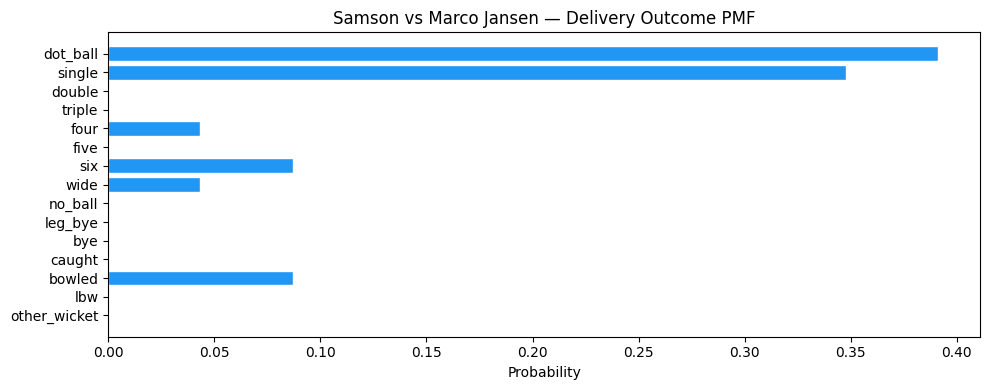

In [7]:
# Visualize a sample matchup probability distribution
sample = prob_df[(prob_df['batter'] == 'Samson') & (prob_df['bowler'] == 'Marco Jansen')].iloc[0]
print(f"Matchup: {sample['batter']} vs {sample['bowler']} (source: {sample['source']})")
print('=' * 55)
for evt in EVENT_CATEGORIES:
    p = sample[f'p_{evt}']
    if p > 0:
        bar = '█' * int(p * 50)
        print(f'  {evt:15s}: {p:.4f} {bar}')

# Bar chart
fig, ax = plt.subplots(figsize=(10, 4))
probs_vals = [sample[f'p_{evt}'] for evt in EVENT_CATEGORIES]
colors = ['#2196F3' if p > 0 else '#E0E0E0' for p in probs_vals]
ax.barh(EVENT_CATEGORIES, probs_vals, color=colors, edgecolor='white')
ax.set_xlabel('Probability')
ax.set_title(f"Samson vs Marco Jansen — Delivery Outcome PMF")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Plotting a Custom Matchup Probability Distribution

Use the code below to visualize the event probability distribution for any batter-bowler combination present in the `prob_df`. Adjust `selected_batter` and `selected_bowler` to see different matchups.

Matchup: Samson vs Maharaj (source: matchup)
  dot_ball       : 0.2174 ██████████
  single         : 0.4783 ███████████████████████
  double         : 0.0435 ██
  four           : 0.1739 ████████
  six            : 0.0870 ████


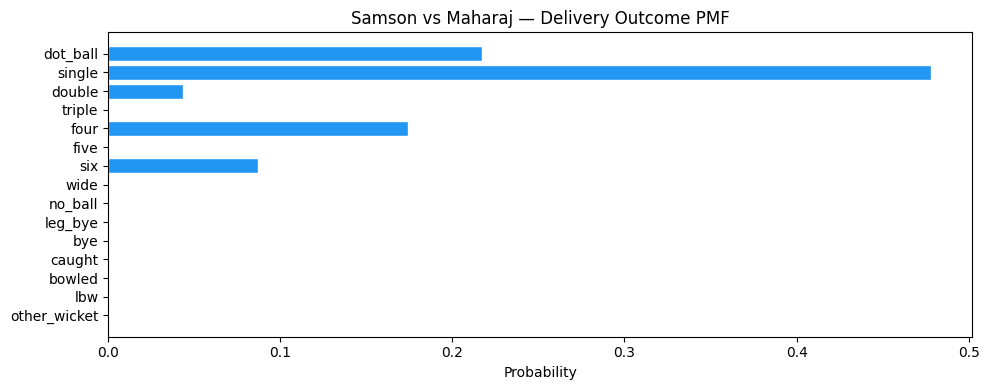

In [8]:
selected_batter = 'Samson'
selected_bowler = 'Maharaj'

# Find the matchup in the probability DataFrame
custom_sample = prob_df[
    (prob_df['batter'] == selected_batter) &
    (prob_df['bowler'] == selected_bowler)
]

if not custom_sample.empty:
    sample_row = custom_sample.iloc[0]
    print(f"Matchup: {sample_row['batter']} vs {sample_row['bowler']} (source: {sample_row['source']})")
    print('=' * 55)
    for evt in EVENT_CATEGORIES:
        p = sample_row[f'p_{evt}']
        if p > 0:
            bar = '█' * int(p * 50)
            print(f'  {evt:15s}: {p:.4f} {bar}')

    # Bar chart
    fig, ax = plt.subplots(figsize=(10, 4))
    probs_vals = [sample_row[f'p_{evt}'] for evt in EVENT_CATEGORIES]
    colors = ['#2196F3' if p > 0 else '#E0E0E0' for p in probs_vals]
    ax.barh(EVENT_CATEGORIES, probs_vals, color=colors, edgecolor='white')
    ax.set_xlabel('Probability')
    ax.set_title(f"{selected_batter} vs {selected_bowler} — Delivery Outcome PMF")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print(f"Matchup data not found for {selected_batter} vs {selected_bowler}.")
    print("Please check batter and bowler names, or choose a different combination.")

## 4. Simulation Pipeline Preparation

Before running simulations, we extract two key inputs from a reference match:

1. **Batting order** — the sequence in which batters appear at the crease
2. **Bowling plan** — which bowler bowls each over (over 0 → bowler A, over 1 → bowler B, ...)

We also convert the probability DataFrame into a **nested dictionary** for $O(1)$ lookup:
```
prob_lookup[batter_name][bowler_name] → numpy array of 15 probabilities
```

In [9]:
def get_batting_order(df, batting_team, match_id=None):
    """Extract batting order based on first appearance of each batter."""
    innings_df = df[df['batting_team'] == batting_team].copy()
    if match_id is not None:
        innings_df = innings_df[innings_df['match_id'] == match_id]
    order, seen = [], set()
    for _, row in innings_df.iterrows():
        batter = row['striker']
        if batter not in seen:
            order.append(batter)
            seen.add(batter)
    return order


def get_bowling_plan(df, batting_team, match_id=None):
    """Extract over-by-over bowling plan: {over_num: bowler_name}."""
    innings_df = df[df['batting_team'] == batting_team].copy()
    if match_id is not None:
        innings_df = innings_df[innings_df['match_id'] == match_id]
    innings_df['over_num'] = innings_df['over'].apply(lambda x: int(float(x)))
    bowling_plan = {}
    for over_num in range(20):
        over_df = innings_df[innings_df['over_num'] == over_num]
        if len(over_df) > 0:
            bowling_plan[over_num] = over_df.iloc[0]['bowler']
    return bowling_plan


def build_probability_lookup(prob_df):
    """Convert probability DataFrame → nested dict for O(1) lookup."""
    lookup = defaultdict(dict)
    prob_cols = [f'p_{evt}' for evt in EVENT_CATEGORIES]
    for _, row in prob_df.iterrows():
        probs = np.array([row[col] for col in prob_cols])
        probs = probs / probs.sum()  # ensure sums to 1
        lookup[row['batter']][row['bowler']] = probs
    return dict(lookup)


# Use first match as reference
first_match = df['match_id'].min()
batting_order = get_batting_order(df, 'IND', match_id=first_match)
bowling_plan = get_bowling_plan(df, 'IND', match_id=first_match)
prob_lookup = build_probability_lookup(prob_df)

print(f'Reference match ID: {first_match}')
print(f'\nIndia batting order:')
for i, b in enumerate(batting_order, 1):
    print(f'  {i}. {b}')

print(f'\nSA bowling plan (over → bowler):')
for over, bowler in sorted(bowling_plan.items()):
    print(f'  Over {over}: {bowler}')

print(f'\nLookup table: {len(prob_lookup)} batters')

Reference match ID: 202401

India batting order:
  1. Samson
  2. Abhishek Sharma
  3. Suryakumar Yadav
  4. Tilak Varma
  5. Hardik Pandya
  6. Rinku Singh
  7. Axar
  8. Arshdeep Singh
  9. Ravi Bishnoi

SA bowling plan (over → bowler):
  Over 0: Marco Jansen
  Over 1: Markram
  Over 2: Maharaj
  Over 3: Gerald Coetzee
  Over 4: Marco Jansen
  Over 5: Gerald Coetzee
  Over 6: Maharaj
  Over 7: Nqabayomzi Peter
  Over 8: Patrick Kruger
  Over 9: Simelane
  Over 10: Maharaj
  Over 11: Nqabayomzi Peter
  Over 12: Simelane
  Over 13: Patrick Kruger
  Over 14: Maharaj
  Over 15: Nqabayomzi Peter
  Over 16: Gerald Coetzee
  Over 17: Marco Jansen
  Over 18: Gerald Coetzee
  Over 19: Marco Jansen

Lookup table: 10 batters


## 5. Monte Carlo Simulation Engine (State Machine)

The core engine is a **state machine** that models a T20 innings ball by ball.

### State Variables
| Variable | Description |
|----------|-------------|
| `total_score` | Cumulative team runs |
| `wickets` | Number of wickets fallen (max 10) |
| `legal_balls` | Count of legal deliveries bowled (max 120) |
| `current_over` | Current over number (0–19) |
| `ball_in_over` | Ball number within the current over (0–5) |
| `striker_idx` | Index into the batting order for the batter on strike |
| `non_striker_idx` | Index for the non-striker |

### Algorithm per delivery
1. Look up `prob_lookup[striker][bowler]` → array of 15 probabilities
2. Sample an event using `np.random.choice(15, p=probs)`
3. Update state based on event type:
   - **Wicket**: increment wickets, bring in next batter
   - **Wide/No-ball**: add 1 run, do **not** count as legal ball
   - **Runs**: add runs to score, swap strike if odd runs
   - **End of over**: swap strike, move to next over/bowler
4. Repeat until 120 legal balls or 10 wickets

### Three output modes
The same engine supports all three simulation levels via the `mode` parameter:
- `mode='score'` → returns just the total score (fastest)
- `mode='scorecard'` → returns per-batter stats dict
- `mode='ball_by_ball'` → returns full delivery log

In [10]:
def simulate_innings(batting_order, bowling_plan, prob_lookup, mode='score', target=None):
    """
    Simulate a single T20 innings using Monte Carlo sampling.

    Parameters
    ----------
    batting_order : list of str — batting lineup
    bowling_plan  : dict {over_num: bowler_name}
    prob_lookup   : dict {batter: {bowler: np.array(15)}}
    mode          : 'score' | 'scorecard' | 'ball_by_ball'
    target        : int optional target score to chase (stops early if reached)

    Returns
    -------
    Depends on mode:
      'score'        → int (total runs)
      'scorecard'    → dict with total_score, wickets, and per-batter stats
      'ball_by_ball' → dict with total_score, wickets, overs, and delivery log
    """
    total_score = 0
    wickets = 0
    legal_balls = 0
    current_over = 0
    ball_in_over = 0
    striker_idx = 0
    non_striker_idx = 1
    next_batter_idx = 2
    max_wickets = 10
    max_legal_balls = 120
    bowlers = list(set(bowling_plan.values()))

    # Per-batter stats tracking (for scorecard & ball_by_ball modes)
    batter_stats = {}
    for b in batting_order:
        batter_stats[b] = {'runs': 0, 'balls_faced': 0, 'fours': 0, 'sixes': 0,
                           'out': False, 'how_out': '', 'bowler_out': ''}

    # Ball-by-ball log (for ball_by_ball mode)
    ball_log = []

    while legal_balls < max_legal_balls and wickets < max_wickets:
        # Determine bowler for this over
        if current_over in bowling_plan:
            bowler = bowling_plan[current_over]
        else:
            bowler = bowlers[current_over % len(bowlers)]

        striker = batting_order[striker_idx]

        # Look up probability distribution
        if striker in prob_lookup and bowler in prob_lookup[striker]:
            probs = prob_lookup[striker][bowler]
        elif striker in prob_lookup:
            all_probs = list(prob_lookup[striker].values())
            probs = np.mean(all_probs, axis=0)
            probs = probs / probs.sum()
        else:
            probs = np.ones(NUM_EVENTS) / NUM_EVENTS

        # Sample outcome
        event_idx = np.random.choice(NUM_EVENTS, p=probs)
        event = EVENT_CATEGORIES[event_idx]

        # --- Process event ---
        runs_scored = 0
        is_legal = True
        is_wicket = False
        swap_strike = False

        if event in ('caught', 'bowled', 'lbw', 'other_wicket'):
            is_wicket = True
            batter_stats[striker]['balls_faced'] += 1
            batter_stats[striker]['out'] = True
            batter_stats[striker]['how_out'] = event
            batter_stats[striker]['bowler_out'] = bowler
            wickets += 1
            legal_balls += 1
            ball_in_over += 1

        elif event == 'wide':
            runs_scored = 1
            total_score += 1
            is_legal = False  # wide doesn't count as legal ball

        elif event == 'no_ball':
            runs_scored = 1
            total_score += 1
            is_legal = False

        elif event == 'leg_bye':
            runs_scored = 1
            total_score += 1
            batter_stats[striker]['balls_faced'] += 1
            legal_balls += 1
            ball_in_over += 1
            swap_strike = True

        elif event == 'bye':
            runs_scored = 1
            total_score += 1
            batter_stats[striker]['balls_faced'] += 1
            legal_balls += 1
            ball_in_over += 1
            swap_strike = True

        else:  # Standard runs: dot, single, double, triple, four, five, six
            runs_map = {'dot_ball': 0, 'single': 1, 'double': 2, 'triple': 3,
                        'four': 4, 'five': 5, 'six': 6}
            runs = runs_map.get(event, 0)
            runs_scored = runs
            total_score += runs
            batter_stats[striker]['runs'] += runs
            batter_stats[striker]['balls_faced'] += 1
            if runs == 4: batter_stats[striker]['fours'] += 1
            if runs == 6: batter_stats[striker]['sixes'] += 1
            legal_balls += 1
            ball_in_over += 1
            if runs % 2 == 1: swap_strike = True

        # Log this delivery (for ball_by_ball mode)
        if mode == 'ball_by_ball':
            ball_log.append({
                'over': f'{current_over}.{ball_in_over}' if is_legal else f'{current_over}.{ball_in_over}*',
                'striker': striker,
                'bowler': bowler,
                'event': event,
                'runs': runs_scored,
                'total': total_score,
                'wickets': wickets
            })

        # Handle wicket — bring in next batter
        if is_wicket:
            if wickets < max_wickets and next_batter_idx < len(batting_order):
                striker_idx = next_batter_idx
                next_batter_idx += 1
            else:
                break

        # Swap strike
        if swap_strike:
            striker_idx, non_striker_idx = non_striker_idx, striker_idx

        # Check target
        if target is not None and total_score >= target:
            break

        # End of over
        if ball_in_over >= 6:
            current_over += 1
            ball_in_over = 0
            striker_idx, non_striker_idx = non_striker_idx, striker_idx

    overs_bowled = f'{current_over}.{ball_in_over}' if ball_in_over > 0 else f'{current_over}.0'
    # --- Return based on mode ---
    if mode == 'score':
        return total_score

    elif mode == 'scorecard':
        scorecard = []
        for b in batting_order:
            s = batter_stats[b]
            if s['balls_faced'] > 0 or s['out']:
                sr = (s['runs'] / s['balls_faced'] * 100) if s['balls_faced'] > 0 else 0
                scorecard.append({
                    'batter': b,
                    'runs': s['runs'],
                    'balls': s['balls_faced'],
                    'fours': s['fours'],
                    'sixes': s['sixes'],
                    'SR': round(sr, 1),
                    'out': s['how_out'] if s['out'] else 'not out',
                    'bowler': s['bowler_out'] if s['out'] else ''
                })
        return {
            'total_score': total_score,
            'wickets': wickets,
            'overs': overs_bowled,
            'scorecard': scorecard
        }

    elif mode == 'ball_by_ball':
        return {
            'total_score': total_score,
            'wickets': wickets,
            'overs': overs_bowled,
            'scorecard': batter_stats,
            'ball_log': ball_log
        }

print('Simulation engine defined. Ready for all 3 levels.')

Simulation engine defined. Ready for all 3 levels.


## Level 3: Ball-by-Ball Simulation

The most detailed level. We simulate a **single innings** by calling `simulate_innings(mode='ball_by_ball')`
and print the complete delivery log, showing what happened on every single ball.

In [11]:
# --- LEVEL 3: Ball-by-Ball Simulation ---
np.random.seed(123)
bbb_result = simulate_innings(batting_order, bowling_plan, prob_lookup, mode='ball_by_ball')

print(f"{'='*70}")
print(f"  INDIA INNINGS — Ball-by-Ball Simulation")
print(f"{'='*70}")
print(f"{'Over':<8} {'Striker':<20} {'Bowler':<20} {'Event':<15} {'Runs':<5} {'Score'}")
print(f"{'─'*70}")

prev_over = -1
for ball in bbb_result['ball_log'][:18]:  # showing first 3 overs for brevity
    over_num = int(ball['over'].split('.')[0])
    if over_num != prev_over and prev_over != -1:
        print(f"{'─'*70}")
    prev_over = over_num
    score_str = f"{ball['total']}/{ball['wickets']}"
    print(f"{ball['over']:<8} {ball['striker']:<20} {ball['bowler']:<20} {ball['event']:<15} {ball['runs']:<5} {score_str}")

print(f"{'─'*70}")
print("... (Deliveries output truncated for brevity) ...")
print(f"{'─'*70}")

for ball in bbb_result['ball_log'][-6:]:  # showing last over for brevity
    score_str = f"{ball['total']}/{ball['wickets']}"
    print(f"{ball['over']:<8} {ball['striker']:<20} {ball['bowler']:<20} {ball['event']:<15} {ball['runs']:<5} {score_str}")

print(f"{'='*70}")
print(f"FINAL: {bbb_result['total_score']}/{bbb_result['wickets']} in {bbb_result['overs']} overs")
print(f"Total deliveries logged: {len(bbb_result['ball_log'])}")

  INDIA INNINGS — Ball-by-Ball Simulation
Over     Striker              Bowler               Event           Runs  Score
──────────────────────────────────────────────────────────────────────
0.1      Samson               Marco Jansen         single          1     1/0
0.2      Abhishek Sharma      Marco Jansen         dot_ball        0     1/0
0.3      Abhishek Sharma      Marco Jansen         dot_ball        0     1/0
0.4      Abhishek Sharma      Marco Jansen         single          1     2/0
0.5      Samson               Marco Jansen         single          1     3/0
0.6      Abhishek Sharma      Marco Jansen         dot_ball        0     3/0
──────────────────────────────────────────────────────────────────────
1.0*     Samson               Markram              wide            1     4/0
1.1      Samson               Markram              single          1     5/0
1.2      Abhishek Sharma      Markram              single          1     6/0
1.3      Samson               Markram       

## Level 2: Full Scorecard Simulation

By passing `mode='scorecard'` to the simulation engine, we track per-batter statistics:
- Runs scored, balls faced, boundaries (4s and 6s)
- Strike rate = (runs / balls) × 100
- How the batter got out (or "not out")

In [12]:
# --- LEVEL 2: Scorecard Simulation ---
np.random.seed(99)
sc_result = simulate_innings(batting_order, bowling_plan, prob_lookup, mode='scorecard')

print(f"{'='*80}")
print(f"  INDIA INNINGS — Simulated Scorecard")
print(f"{'='*80}")
print(f"{'Batter':<22} {'Dismissal':<18} {'Bowler':<18} {'R':>4} {'B':>4} {'4s':>3} {'6s':>3} {'SR':>7}")
print(f"{'─'*80}")

for entry in sc_result['scorecard']:
    print(f"{entry['batter']:<22} {entry['out']:<18} {entry['bowler']:<18} "
          f"{entry['runs']:>4} {entry['balls']:>4} {entry['fours']:>3} {entry['sixes']:>3} {entry['SR']:>7}")

print(f"{'─'*80}")
print(f"TOTAL: {sc_result['total_score']}/{sc_result['wickets']} ({sc_result['overs']} overs)")
print(f"{'='*80}")

  INDIA INNINGS — Simulated Scorecard
Batter                 Dismissal          Bowler                R    B  4s  6s      SR
────────────────────────────────────────────────────────────────────────────────
Samson                 caught             Nqabayomzi Peter     67   26   5   6   257.7
Abhishek Sharma        other_wicket       Maharaj              18   13   3   0   138.5
Suryakumar Yadav       caught             Simelane             21   22   0   2    95.5
Tilak Varma            not out                                 44   28   5   1   157.1
Hardik Pandya          caught             Gerald Coetzee       17   20   2   0    85.0
Rinku Singh            not out                                 20   11   3   0   181.8
────────────────────────────────────────────────────────────────────────────────
TOTAL: 199/4 (20.0 overs)


## Level 1: Total Score Projection (1000 Monte Carlo Simulations)

We run the simulation engine **1000 times** in `mode='score'` (fastest mode, returns only the total).
This gives us a **distribution of projected team totals** from which we can compute:
- Mean and median projected score
- Standard deviation (measure of uncertainty)
- Percentiles (confidence intervals)

In [13]:
# --- LEVEL 1: 1000 Monte Carlo Simulations ---
N_SIMS = 1000
np.random.seed(42)
print(f'Running {N_SIMS} Monte Carlo simulations (score-only mode)...')

simulated_scores = np.array([
    simulate_innings(batting_order, bowling_plan, prob_lookup, mode='score')
    for _ in range(N_SIMS)
])

print(f'Done!\n')
print(f'╔══════════════════════════════════════════════╗')
print(f'║  Projected Score Statistics (India batting)  ║')
print(f'╠══════════════════════════════════════════════╣')
print(f'║  Mean score:    {np.mean(simulated_scores):>7.1f}                      ║')
print(f'║  Median score:  {np.median(simulated_scores):>7.1f}                      ║')
print(f'║  Std deviation: {np.std(simulated_scores):>7.1f}                      ║')
print(f'║  Min score:     {np.min(simulated_scores):>7d}                      ║')
print(f'║  Max score:     {np.max(simulated_scores):>7d}                      ║')
print(f'║  25th pctile:   {np.percentile(simulated_scores, 25):>7.0f}                      ║')
print(f'║  75th pctile:   {np.percentile(simulated_scores, 75):>7.0f}                      ║')
print(f'╚══════════════════════════════════════════════╝')

Running 1000 Monte Carlo simulations (score-only mode)...
Done!

╔══════════════════════════════════════════════╗
║  Projected Score Statistics (India batting)  ║
╠══════════════════════════════════════════════╣
║  Mean score:      189.9                      ║
║  Median score:    189.0                      ║
║  Std deviation:    33.1                      ║
║  Min score:          87                      ║
║  Max score:         297                      ║
║  25th pctile:       168                      ║
║  75th pctile:       212                      ║
╚══════════════════════════════════════════════╝


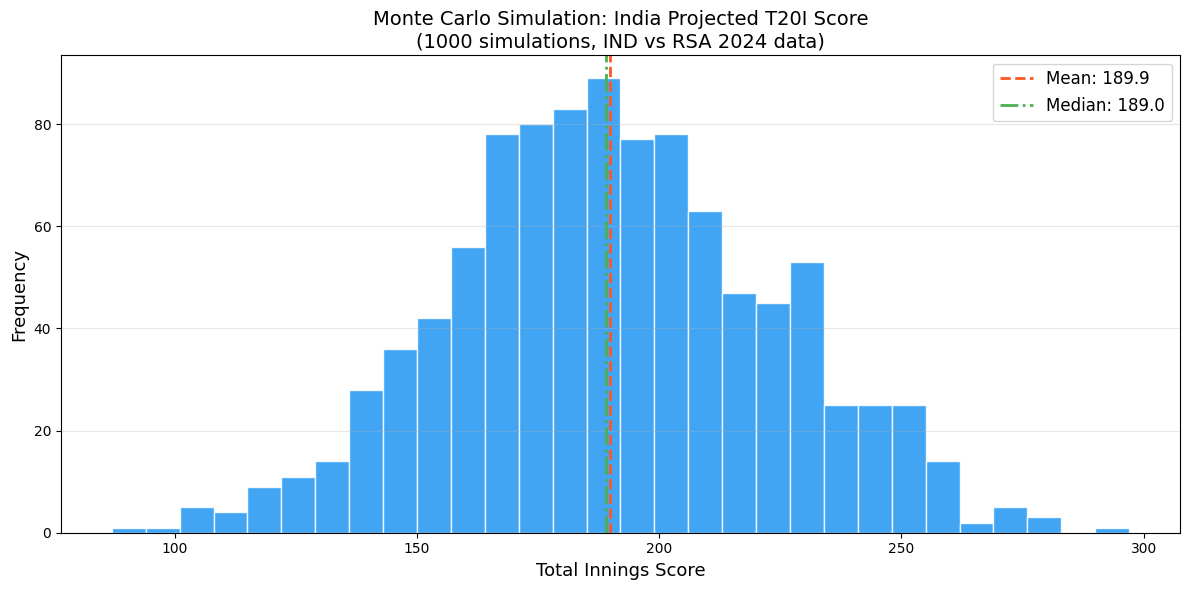

Histogram saved as score_distribution.png


In [14]:
# Plot the distribution of simulated scores
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(simulated_scores, bins=30, color='#2196F3', edgecolor='white', alpha=0.85, density=False)

# Add vertical lines for mean and median
mean_score = np.mean(simulated_scores)
median_score = np.median(simulated_scores)

ax.axvline(mean_score, color='#FF5722', linewidth=2, linestyle='--', label=f'Mean: {mean_score:.1f}')
ax.axvline(median_score, color='#4CAF50', linewidth=2, linestyle='-.', label=f'Median: {median_score:.1f}')

ax.set_xlabel('Total Innings Score', fontsize=13)
ax.set_ylabel('Frequency', fontsize=13)
ax.set_title(f'Monte Carlo Simulation: India Projected T20I Score\n({N_SIMS} simulations, IND vs RSA 2024 data)', fontsize=14)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Histogram saved as score_distribution.png')

## Advanced Analytics: Worm Charts & Boxplots

To better understand the pacing of the innings, we can plot the **Cumulative Run Progression (Worm Chart)** for 10 random simulations.
We also plot a **Boxplot** to visualize the Interquartile Range (middle 50% of projected scores) against the extremes.

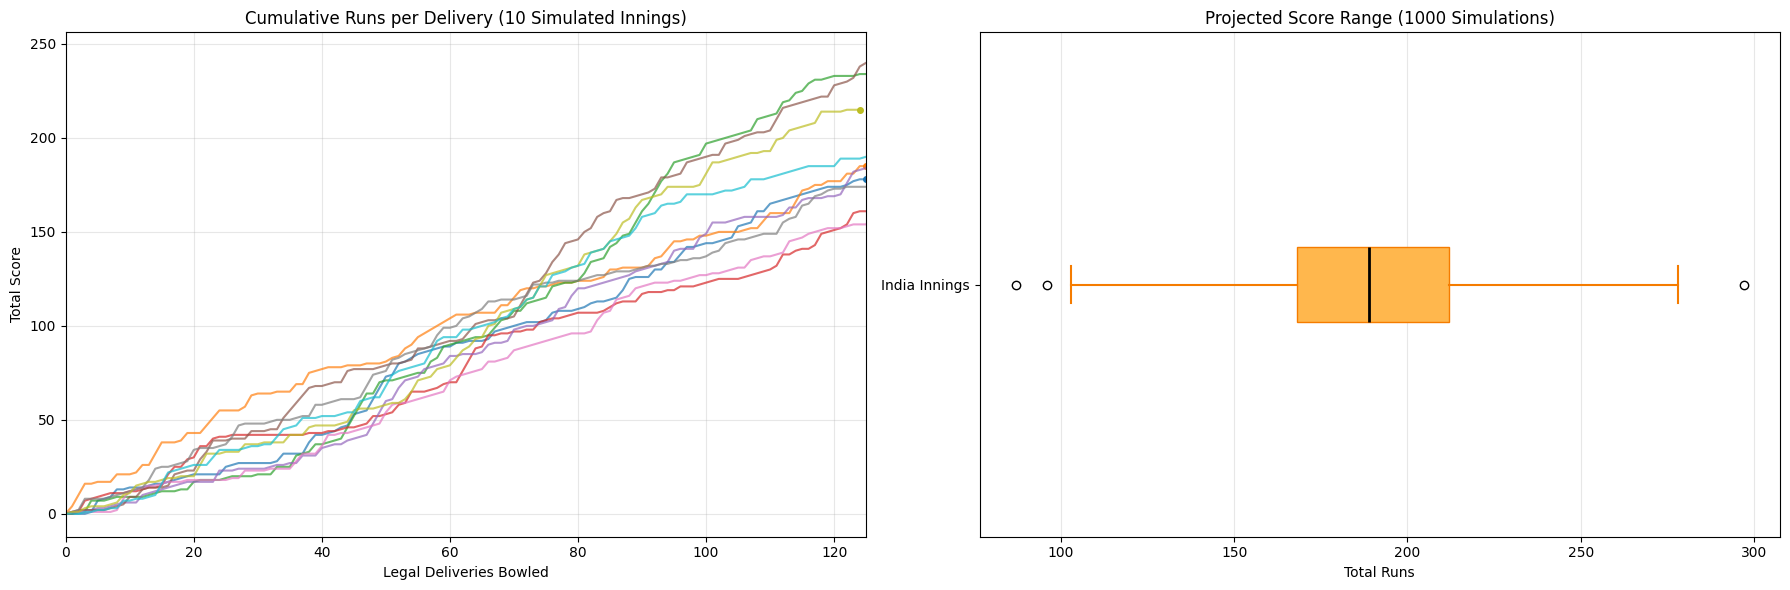

In [15]:
# --- 1. Generate Worm Chart Data (10 runs) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

np.random.seed(777)
COLORS = plt.cm.tab10.colors
for i in range(10):
    result = simulate_innings(batting_order, bowling_plan, prob_lookup, mode='ball_by_ball')
    log = result['ball_log']
    runs_cumulative = [0] + [ball['total'] for ball in log]
    balls = list(range(len(runs_cumulative)))
    ax1.plot(balls, runs_cumulative, color=COLORS[i % 10], alpha=0.7, linewidth=1.5)
    ax1.plot(balls[-1], runs_cumulative[-1], marker='o', markersize=4, color=COLORS[i % 10])

ax1.set_title('Cumulative Runs per Delivery (10 Simulated Innings)')
ax1.set_xlabel('Legal Deliveries Bowled')
ax1.set_ylabel('Total Score')
ax1.grid(alpha=0.3)
ax1.set_xlim(0, 125)

# --- 2. Boxplot of 1000 Total Scores ---
ax2.boxplot(simulated_scores, vert=False, patch_artist=True,
            boxprops=dict(facecolor='#FFB74D', color='#F57C00'),
            medianprops=dict(color='black', linewidth=2),
            whiskerprops=dict(color='#F57C00', linewidth=1.5),
            capprops=dict(color='#F57C00', linewidth=1.5))

ax2.set_title('Projected Score Range (1000 Simulations)')
ax2.set_xlabel('Total Runs')
ax2.set_yticklabels(['India Innings'])
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Level 4: Full Match Simulation (Estimating Win Probabilities)

To estimate the probability distribution of match results separated by who bats first, we generate probabilities for **South Africa (RSA)** as well, and run full match chases:
- **Case 1**: India bats first and sets a target. RSA chases.
- **Case 2**: RSA bats first and sets a target. India chases.

We run 1000 Monte-Carlo simulated matches for both cases to extract empirical Win/Loss probabilities.

In [16]:
# --- 1. Compute RSA batting probabilities & Extract Info ---
prob_df_rsa = compute_matchup_probabilities(df, batting_team='RSA', bowling_team='IND')
prob_lookup_rsa = build_probability_lookup(prob_df_rsa)
rsa_batting_order = get_batting_order(df, 'RSA', match_id=first_match)
rsa_bowling_plan = get_bowling_plan(df, 'RSA', match_id=first_match)

# --- 2. Full Match Simulator ---
def simulate_full_match(team1_order, team1_bowlers, team1_lookup,
                        team2_order, team2_bowlers, team2_lookup):
    # Team 1 bats first without a target limit
    team1_score = simulate_innings(team1_order, team1_bowlers, team1_lookup, mode='score', target=None)
    target = team1_score + 1

    # Team 2 bats second chasing target
    team2_score = simulate_innings(team2_order, team2_bowlers, team2_lookup, mode='score', target=target)

    if team2_score >= target:
        return 'Team 2 Win'
    elif team2_score == team1_score:
        return 'Tie'
    else:
        return 'Team 1 Win'

# --- 3. Run Monte Carlo for Case 1 (IND bats first) ---
print("Simulating 1000 matches: IND bats first, RSA chases...")
np.random.seed(42)
case1_results = []
for _ in range(1000):
    res = simulate_full_match(batting_order, rsa_bowling_plan, prob_lookup,
                              rsa_batting_order, bowling_plan, prob_lookup_rsa)
    # Map standard return to actual team names
    if res == 'Team 1 Win': case1_results.append('IND')
    elif res == 'Team 2 Win': case1_results.append('RSA')
    else: case1_results.append('Tie')

# --- 4. Run Monte Carlo for Case 2 (RSA bats first) ---
print("Simulating 1000 matches: RSA bats first, IND chases...")
case2_results = []
for _ in range(1000):
    res = simulate_full_match(rsa_batting_order, bowling_plan, prob_lookup_rsa,
                              batting_order, rsa_bowling_plan, prob_lookup)
    if res == 'Team 1 Win': case2_results.append('RSA')
    elif res == 'Team 2 Win': case2_results.append('IND')
    else: case2_results.append('Tie')

def print_distribution(case_name, results):
    ind = results.count('IND') / len(results)
    rsa = results.count('RSA') / len(results)
    tie = results.count('Tie') / len(results)
    print(f"\n{case_name}")
    print(f"{'-'*40}")
    print(f"India   Win Prob: {ind*100:.1f}%")
    print(f"RSA     Win Prob: {rsa*100:.1f}%")
    print(f"Tie / Super Over: {tie*100:.1f}%")

print_distribution("Case 1: IND bats first, RSA chases", case1_results)
print_distribution("Case 2: RSA bats first, IND chases", case2_results)
print("\nMatch Probability Distribution successfully estimated!")


Simulating 1000 matches: IND bats first, RSA chases...
Simulating 1000 matches: RSA bats first, IND chases...

Case 1: IND bats first, RSA chases
----------------------------------------
India   Win Prob: 87.7%
RSA     Win Prob: 12.1%
Tie / Super Over: 0.2%

Case 2: RSA bats first, IND chases
----------------------------------------
India   Win Prob: 86.1%
RSA     Win Prob: 13.4%
Tie / Super Over: 0.5%

Match Probability Distribution successfully estimated!


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_win_probabilities(results, case_name, team1_name, team2_name):
    probs = get_probs(results, team1_name, team2_name)
    teams = list(probs.keys())
    win_percentages = [p * 100 for p in probs.values()]

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(x=teams, y=win_percentages, palette='viridis', ax=ax)

    ax.set_title(f'Match Outcome Probabilities: {case_name}')
    ax.set_ylabel('Probability (%)')
    ax.set_ylim(0, 100)

    for i, p in enumerate(win_percentages):
        ax.text(i, p + 2, f'{p:.1f}%', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

print("Plotting function 'plot_win_probabilities' defined.")

Plotting function 'plot_win_probabilities' defined.


### Visualizing Match Win Probabilities

In [18]:
# Create lookup for RSA batting against India bowling
prob_df_rsa = compute_matchup_probabilities(df, batting_team='RSA', bowling_team='IND')
prob_lookup_rsa = build_probability_lookup(prob_df_rsa)

# Get RSA batting order and IND bowling plan
rsa_batting_order = get_batting_order(df, 'RSA', match_id=first_match)
ind_bowling_plan = get_bowling_plan(df, 'RSA', match_id=first_match) # Note: 'RSA' is the batting team here

In [19]:
def simulate_full_match(team1_data, team2_data, team1_first=True):
    """
    Simulates a full match where Team 1 bats first and Team 2 chases.
    Returns: 'Team 1 Win', 'Team 2 Win', or 'Tie'
    """
    # Innings 1
    if team1_first:
        score1 = simulate_innings(team1_data['order'], team1_data['plan'], team1_data['lookup'], mode='score')
        # Innings 2 (The Chase)
        score2 = simulate_innings(team2_data['order'], team2_data['plan'], team2_data['lookup'], mode='score', target=score1 + 1)
    else:
        score1 = simulate_innings(team2_data['order'], team2_data['plan'], team2_data['lookup'], mode='score')
        score2 = simulate_innings(team1_data['order'], team1_data['plan'], team1_data['lookup'], mode='score', target=score1 + 1)

    if score2 > score1:
        return "RSA Win" if (team1_first) else "IND Win" # Simplify based on your teams
    elif score2 < score1:
        return "IND Win" if (team1_first) else "RSA Win"
    else:
        return "Tie"

In [20]:
# Data structures for the function
ind_info = {'order': batting_order, 'plan': ind_bowling_plan, 'lookup': prob_lookup}
rsa_info = {'order': rsa_batting_order, 'plan': bowling_plan, 'lookup': prob_lookup_rsa}

# Case 1: IND bats first, RSA chases
case1_results = [simulate_full_match(ind_info, rsa_info, team1_first=True) for _ in range(1000)]

# Case 2: RSA bats first, IND chases
case2_results = [simulate_full_match(ind_info, rsa_info, team1_first=False) for _ in range(1000)]

In [21]:
print(case1_results)

['IND Win', 'RSA Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'RSA Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'RSA Win', 'RSA Win', 'RSA Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'RSA Win', 'IND Win', 'RSA Win', 'IND Win', 'IND Win', 'RSA Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'RSA Win', 'RSA Win', 'IND Win', 'IND Win', 'IND Win', 'RSA Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'RSA Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'RSA Win', 'IND Win', 'IND Win', 'IND Win', 'RSA Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'RSA Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'RSA Win', 'IND Win', 'RSA Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win'

In [22]:
print(case2_results)

['IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'RSA Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'RSA Win', 'IND Win', 'RSA Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'RSA Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'RSA Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'Tie', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'RSA Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'IND Win', 'RSA Win', 'IND Win', 'I

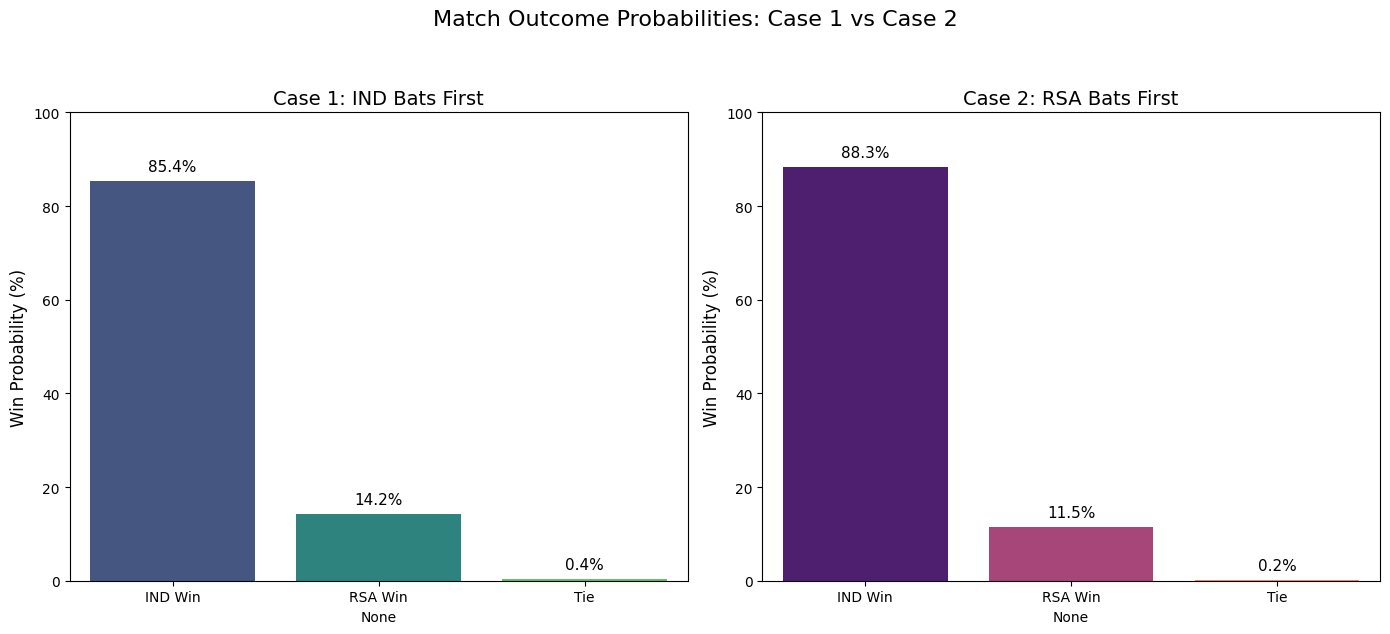

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_case_distributions(case1_res, case2_res):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Calculate percentages for Case 1
    c1_counts = pd.Series(case1_res).value_counts(normalize=True) * 100
    c1_counts = c1_counts.sort_index()

    sns.barplot(x=c1_counts.index, y=c1_counts.values, ax=axes[0], palette='viridis')
    axes[0].set_title('Case 1: IND Bats First', fontsize=14)
    axes[0].set_ylabel('Win Probability (%)', fontsize=12)
    axes[0].set_ylim(0, 100)
    for p in axes[0].patches:
        axes[0].annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()), \
                         ha='center', va='bottom', fontsize=11, xytext=(0, 5), textcoords='offset points')

    # Calculate percentages for Case 2
    c2_counts = pd.Series(case2_res).value_counts(normalize=True) * 100
    c2_counts = c2_counts.sort_index()

    sns.barplot(x=c2_counts.index, y=c2_counts.values, ax=axes[1], palette='magma')
    axes[1].set_title('Case 2: RSA Bats First', fontsize=14)
    axes[1].set_ylabel('Win Probability (%)', fontsize=12)
    axes[1].set_ylim(0, 100)
    for p in axes[1].patches:
        axes[1].annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()), \
                         ha='center', va='bottom', fontsize=11, xytext=(0, 5), textcoords='offset points')

    plt.suptitle('Match Outcome Probabilities: Case 1 vs Case 2', fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

# Call the function to plot distributions
plot_case_distributions(case1_results, case2_results)
